# Stage 1 — Linear Probe Baseline

This Colab notebook evaluates frozen **ImageNet-1K ResNet-18** and **DINOv2 ViT-S/14** features with a learned multiclass linear head on **DTD partition 1**, **FGVC-Aircraft (variant)**, and **Oxford Flowers-102**. It preserves official train/validation/test splits, caches features once, evaluates 5-shot, 10-shot, and full-data settings, and reports the Stage 1 metrics and visualizations. No Flow Matching component is used.

Run all cells from top to bottom. The full grid is compute-intensive; cached features make repeat runs much faster.

## 1. Install dependencies

In [1]:
%pip -q install open_clip_torch scikit-learn pandas seaborn tqdm


## 2. Mount Drive and configure paths
Set `USE_DRIVE=False` to use temporary Colab storage. All artifacts are grouped below `OUTPUT_ROOT`.

In [2]:
from pathlib import Path
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Flow-Matching')
else:
    PROJECT_ROOT = Path('/content/Flow-Matching')
PERSISTENT_DATA_ROOT = PROJECT_ROOT / 'data'
DATA_ROOT = Path('/content/flow_matching_data') if Path('/content').exists() else PERSISTENT_DATA_ROOT
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'linear_probe'
CACHE_ROOT = PROJECT_ROOT / 'feature_cache'
for p in [DATA_ROOT, OUTPUT_ROOT, CACHE_ROOT]: p.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Flow-Matching


## 3. Imports, hardware, and reproducibility
Subset seeds select few-shot examples. Full-data repetitions use classifier-initialization seeds. The test split is never used for checkpoint selection.

In [ ]:
import copy, json, math, os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
import open_clip

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
print('Device:', DEVICE, '| GPU:', torch.cuda.get_device_name(0) if PIN_MEMORY else 'none')

DEFAULT_STAGE1 = {
    'config_revision': 3,
    'plan': {
        'datasets': ['dtd', 'aircraft', 'flowers102'],
        'encoders_by_dataset': {
            'dtd': ['resnet18', 'dinov2_vits14'],
            'aircraft': ['resnet18', 'dinov2_vits14'],
            'flowers102': ['resnet18', 'dinov2_vits14']
        },
        'prototype_branch': 'all', 'prototype_branches': ['image', 'zero_shot_clip'],
        'shots': [5, 10, 'full'],
        'subset_seeds': [0, 1, 2], 'init_seeds': [0, 1, 2],
        'rationale': 'Comprehensive evaluation across all datasets, encoders, and prototype branches.'
    },
    'feature_cache': {'schema_version': 2, 'batch_size': 64, 'num_workers': 0},
    'linear_probe': {
        'batch_size': 64, 'max_epochs': 200, 'early_stopping_patience': 25,
        'lr_patience': 10, 'min_delta': 1e-4, 'checkpoint_interval': 10, 'resume_training': True,
        'candidates': [
            {'name': 'l2_adamw_3e-3', 'feature_transform': 'l2', 'learning_rate': 3e-3, 'weight_decay': 1e-4},
            {'name': 'l2_adamw_1e-3_wd1e-3', 'feature_transform': 'l2', 'learning_rate': 1e-3, 'weight_decay': 1e-3},
            {'name': 'standardize_adamw_1e-3', 'feature_transform': 'standardize', 'learning_rate': 1e-3, 'weight_decay': 1e-4}
        ]
    },
}
config_paths = [
    PROJECT_ROOT / 'stage1_config.json',
    Path.cwd() / 'stage1_config.json',
    Path('/content/stage1_config.json'),
]
config_path = next((p for p in config_paths if p.exists()), None)
if config_path is None:
    STAGE1 = copy.deepcopy(DEFAULT_STAGE1)
    config_path = PROJECT_ROOT / 'stage1_config.json'
    config_path.parent.mkdir(parents=True, exist_ok=True)
    config_path.write_text(json.dumps(STAGE1, indent=2))
    print('Created configuration at:', config_path)
else:
    with config_path.open() as f: STAGE1 = json.load(f)
    print('Loaded configuration from:', config_path)
if STAGE1.get('config_revision', 0) < DEFAULT_STAGE1['config_revision']:
    STAGE1['plan'] = copy.deepcopy(DEFAULT_STAGE1['plan'])
    STAGE1['feature_cache'].update(DEFAULT_STAGE1['feature_cache'])
    STAGE1['linear_probe'].update(DEFAULT_STAGE1['linear_probe'])
    STAGE1['config_revision'] = DEFAULT_STAGE1['config_revision']
    config_path.write_text(json.dumps(STAGE1, indent=2))
    print('Migrated configuration to revision:', STAGE1['config_revision'])
if not STAGE1.get('linear_probe', {}).get('candidates'):
    STAGE1['linear_probe'] = copy.deepcopy(DEFAULT_STAGE1['linear_probe'])
    config_path.write_text(json.dumps(STAGE1, indent=2))
PLAN, PROBE = STAGE1['plan'], STAGE1['linear_probe']
DATASETS = PLAN['datasets']
ENCODERS_BY_DATASET = PLAN['encoders_by_dataset']
ENABLED_PAIRS = [(d, e) for d in DATASETS for e in ENCODERS_BY_DATASET[d]]
ENCODERS = list(dict.fromkeys(e for _, e in ENABLED_PAIRS))
SHOT_SETTINGS = PLAN['shots']
SUBSET_SEEDS = PLAN['subset_seeds']
INIT_SEEDS = PLAN['init_seeds']
BATCH_SIZE_IMAGES = STAGE1['feature_cache']['batch_size']
BATCH_SIZE_HEAD = PROBE['batch_size']
MAX_EPOCHS = PROBE['max_epochs']
IS_COLAB = Path('/content').exists()
NUM_WORKERS = 0 if IS_COLAB else STAGE1['feature_cache']['num_workers']
if IS_COLAB and STAGE1['feature_cache']['num_workers'] != 0:
    print('Colab kernel detected: overriding num_workers=0 for stable VS Code execution.')
if DEVICE.type == 'cuda': torch.backends.cudnn.benchmark = True
CACHE_SCHEMA_VERSION = STAGE1['feature_cache']['schema_version']
CACHE_ROOT = PROJECT_ROOT / 'feature_cache' / f'v{CACHE_SCHEMA_VERSION}'
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_INTERVAL = PROBE['checkpoint_interval']
RESUME_TRAINING = PROBE['resume_training']
LR_PATIENCE = PROBE['lr_patience']
EARLY_STOPPING_PATIENCE = PROBE['early_stopping_patience']
MIN_DELTA = PROBE['min_delta']
CANDIDATES = PROBE['candidates']

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(0)
CONFIG = dict(STAGE1, enabled_pairs=ENABLED_PAIRS, optimizer='AdamW', selection_metric='validation_accuracy')
_ = (OUTPUT_ROOT / 'config.json').write_text(json.dumps(CONFIG, indent=2))
print('Dataset root:', DATA_ROOT)
print('DataLoader workers:', NUM_WORKERS, '| default image batch:', BATCH_SIZE_IMAGES)


## 4. Official datasets and frozen encoders
Torchvision supplies the official splits. DTD explicitly uses partition 1 and Aircraft explicitly uses the `variant` label level. Each encoder uses its checkpoint-associated preprocessing.

In [4]:
def build_dataset(name, split, transform):
    if name == 'dtd':
        return datasets.DTD(DATA_ROOT, split=split, partition=1, transform=transform, download=True)
    if name == 'aircraft':
        return datasets.FGVCAircraft(DATA_ROOT, split=split, annotation_level='variant', transform=transform, download=True)
    if name == 'flowers102':
        return datasets.Flowers102(DATA_ROOT, split=split, transform=transform, download=True)
    raise ValueError(name)

def targets_of(ds):
    for attr in ('_labels', 'targets', 'labels'):
        if hasattr(ds, attr): return np.asarray(getattr(ds, attr), dtype=int)
    return np.asarray([ds[i][1] for i in range(len(ds))], dtype=int)

def class_names_of(ds):
    if hasattr(ds, 'classes'): return [str(x).replace('_', ' ') for x in ds.classes]
    n = int(targets_of(ds).max()) + 1
    return [f'class {i + 1}' for i in range(n)]

def load_encoder(name):
    if name == 'resnet18':
        weights = ResNet18_Weights.IMAGENET1K_V1
        net = models.resnet18(weights=weights)
        net.fc = nn.Identity()
        preprocess = weights.transforms()
        dim = 512; checkpoint_id = 'torchvision/resnet18/IMAGENET1K_V1'
    elif name == 'dinov2_vits14':
        net = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        preprocess = transforms.Compose([transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
        dim = 384; checkpoint_id = 'facebookresearch/dinov2/dinov2_vits14'
    elif name == 'clip_rn50':
        net, _, preprocess = open_clip.create_model_and_transforms('RN50', pretrained='openai')
        class CLIPImageEncoder(nn.Module):
            def __init__(self, clip_model): super().__init__(); self.clip_model = clip_model
            def forward(self, x): return self.clip_model.encode_image(x)
        net = CLIPImageEncoder(net)
        dim = 1024; checkpoint_id = 'open_clip/RN50/openai'
    else: raise ValueError(name)
    net.eval().to(DEVICE)
    for p in net.parameters(): p.requires_grad_(False)
    assert not any(p.requires_grad for p in net.parameters())
    return net, preprocess, dim, checkpoint_id

@torch.inference_mode()
def extract_split(dataset_name, split, encoder_name, encoder, preprocess, checkpoint_id, feature_dim):
    cache = CACHE_ROOT / f'{dataset_name}__{encoder_name}__{split}.pt'
    expected = dict(schema_version=CACHE_SCHEMA_VERSION, dataset=dataset_name, split=split, encoder=encoder_name, checkpoint_id=checkpoint_id, feature_dim=feature_dim)
    if cache.exists():
        item = torch.load(cache, map_location='cpu', weights_only=False)
        actual = {k: item.get(k) for k in expected}
        if actual == expected and len(item['features']) == len(item['labels']) and torch.isfinite(item['features']).all():
            return item
        print(f'Ignoring incompatible cache: {cache.name}')
    ds = build_dataset(dataset_name, split, preprocess)
    batch_size = min(BATCH_SIZE_IMAGES, 32) if encoder_name.startswith('dinov2') else min(BATCH_SIZE_IMAGES, 64)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    print(f'Extracting {dataset_name}/{encoder_name}/{split}: {len(ds)} images, batch={batch_size}, workers={NUM_WORKERS}')
    features, labels = [], []
    for images, y in tqdm(loader, desc=f'{dataset_name}/{encoder_name}/{split}'):
        z = encoder(images.to(DEVICE, non_blocking=True)).float().cpu()
        features.append(z); labels.append(y.long())
    item = dict(features=torch.cat(features), labels=torch.cat(labels), classes=class_names_of(ds), checkpoint_id=checkpoint_id, feature_dim=feature_dim, schema_version=CACHE_SCHEMA_VERSION, dataset=dataset_name, split=split, encoder=encoder_name)
    assert len(item['features']) == len(ds) == len(item['labels'])
    assert torch.isfinite(item['features']).all()
    torch.save(item, cache)
    return item


## 5. Extract and cache train/validation/test features
This is the expensive encoder pass. Re-running the notebook loads the cache instead.

In [5]:
feature_bank = {}
for encoder_name in ENCODERS:
    encoder, preprocess, feature_dim, checkpoint_id = load_encoder(encoder_name)
    for dataset_name, enabled_encoder in ENABLED_PAIRS:
        if enabled_encoder != encoder_name: continue
        feature_bank[(dataset_name, encoder_name)] = {split: extract_split(dataset_name, split, encoder_name, encoder, preprocess, checkpoint_id, feature_dim) for split in ('train', 'val', 'test')}
    del encoder
    if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Cached combinations:', list(feature_bank))


100%|██████████| 2.75G/2.75G [02:04<00:00, 22.0MB/s] 


Extracting aircraft/resnet18/train: 3334 images, batch=64, workers=0


aircraft/resnet18/train:   0%|          | 0/53 [00:00<?, ?it/s]

Extracting aircraft/resnet18/val: 3333 images, batch=64, workers=0


aircraft/resnet18/val:   0%|          | 0/53 [00:00<?, ?it/s]

...

Extracting aircraft/dinov2_vits14/val: 3333 images, batch=32, workers=0


aircraft/dinov2_vits14/val:   0%|          | 0/105 [00:00<?, ?it/s]

Extracting aircraft/dinov2_vits14/test: 3333 images, batch=32, workers=0


aircraft/dinov2_vits14/test:   0%|          | 0/105 [00:00<?, ?it/s]

Cached combinations: [('dtd', 'resnet18'), ('aircraft', 'resnet18'), ('flowers102', 'resnet18'), ('dtd', 'dinov2_vits14'), ('aircraft', 'dinov2_vits14'), ('flowers102', 'dinov2_vits14')]


## 6. Few-shot manifests and linear-head training
The best checkpoint is selected by full validation accuracy. For 5/10-shot runs, the run seed controls the balanced subset; for full-data runs it controls only classifier initialization.

In [6]:
def balanced_indices(labels, k, seed):
    labels = np.asarray(labels); rng = np.random.default_rng(seed); chosen = []
    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        if len(idx) < k: raise ValueError(f'class {c} has {len(idx)} samples, fewer than K={k}')
        chosen.extend(rng.choice(idx, size=k, replace=False).tolist())
    return np.asarray(sorted(chosen))

def eval_head(head, x, y, criterion):
    head.eval(); total_loss = 0.0; predictions = []
    loader = DataLoader(TensorDataset(x, y), batch_size=512, shuffle=False)
    with torch.inference_mode():
        for xb, yb in loader:
            logits = head(xb.to(DEVICE)); total_loss += criterion(logits, yb.to(DEVICE)).item() * len(yb)
            predictions.append(logits.argmax(1).cpu())
    pred = torch.cat(predictions)
    return total_loss / len(y), (pred == y).float().mean().item(), pred

def transform_features(x_train, x_eval, mode):
    if mode == 'l2':
        return F.normalize(x_train, dim=1), F.normalize(x_eval, dim=1), torch.zeros(x_train.shape[1]), torch.ones(x_train.shape[1])
    if mode == 'standardize':
        mean, std = x_train.mean(0), x_train.std(0, unbiased=False).clamp_min(1e-5)
        return (x_train - mean) / std, (x_eval - mean) / std, mean, std
    if mode == 'none':
        return x_train, x_eval, torch.zeros(x_train.shape[1]), torch.ones(x_train.shape[1])
    raise ValueError(f'Unknown feature transform: {mode}')

def select_candidate(x_train, y_train, x_val, y_val, n_classes, seed):
    criterion = nn.CrossEntropyLoss(); rows = []
    for candidate in CANDIDATES:
        seed_everything(seed)
        xt, xv, _, _ = transform_features(x_train, x_val, candidate['feature_transform'])
        head = nn.Linear(xt.shape[1], n_classes).to(DEVICE)
        optimizer = torch.optim.AdamW(head.parameters(), lr=candidate['learning_rate'], weight_decay=candidate['weight_decay'])
        best, stale = -1.0, 0
        for epoch in range(1, min(MAX_EPOCHS, 80) + 1):
            generator = torch.Generator().manual_seed(seed * 100000 + epoch)
            loader = DataLoader(TensorDataset(xt, y_train), batch_size=BATCH_SIZE_HEAD, shuffle=True, generator=generator)
            head.train()
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE); optimizer.zero_grad(set_to_none=True)
                loss = criterion(head(xb), yb); loss.backward(); optimizer.step()
            _, val_acc, _ = eval_head(head, xv, y_val, criterion)
            if val_acc > best + MIN_DELTA: best, stale = val_acc, 0
            else: stale += 1
            if stale >= 10: break
        rows.append(dict(candidate=candidate['name'], validation_accuracy=best, epochs=epoch))
    table = pd.DataFrame(rows).sort_values(['validation_accuracy', 'candidate'], ascending=[False, True])
    winner = next(c for c in CANDIDATES if c['name'] == table.iloc[0].candidate)
    return winner, table

def train_linear_run(bank, dataset_name, encoder_name, shot, subset_seed, init_seed, candidate=None):
    seed_everything(init_seed)
    x_train, y_train = bank['train']['features'].float(), bank['train']['labels'].long()
    if shot != 'full':
        idx = torch.as_tensor(balanced_indices(y_train.numpy(), int(shot), subset_seed))
        x_train, y_train = x_train[idx], y_train[idx]
    x_val, y_val = bank['val']['features'].float(), bank['val']['labels'].long()
    x_test, y_test = bank['test']['features'].float(), bank['test']['labels'].long()
    n_classes = len(bank['train']['classes'])
    if candidate is None:
        candidate, tuning_table = select_candidate(x_train, y_train, x_val, y_val, n_classes, init_seed)
    else:
        tuning_table = pd.DataFrame([dict(candidate=candidate['name'], validation_accuracy=np.nan, epochs=0, reused=True)])
    x_train, x_val, feature_mean, feature_std = transform_features(x_train, x_val, candidate['feature_transform'])
    if candidate['feature_transform'] == 'l2': x_test = F.normalize(x_test, dim=1)
    elif candidate['feature_transform'] == 'standardize': x_test = (x_test - feature_mean) / feature_std
    seed_everything(init_seed)
    head = nn.Linear(x_train.shape[1], n_classes).to(DEVICE)
    optimizer = torch.optim.AdamW(head.parameters(), lr=candidate['learning_rate'], weight_decay=candidate['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=LR_PATIENCE)
    criterion = nn.CrossEntropyLoss(); best_acc = -1.0; best_state = None; history = []; start_epoch = 1; stale_epochs = 0
    run_tag = f'subset_{subset_seed}__init_{init_seed}'
    run_dir = OUTPUT_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / run_tag
    checkpoint_dir = run_dir / 'checkpoints'; checkpoint_dir.mkdir(parents=True, exist_ok=True)
    latest_path, best_path = checkpoint_dir / 'latest.pt', checkpoint_dir / 'best.pt'
    run_config = dict(CONFIG, dataset=dataset_name, encoder=encoder_name, shot=str(shot), subset_seed=subset_seed, init_seed=init_seed, input_dim=x_train.shape[1], num_classes=n_classes, **candidate)
    (run_dir / 'config.json').write_text(json.dumps(run_config, indent=2))
    tuning_table.to_csv(run_dir / 'validation_tuning.csv', index=False)
    if RESUME_TRAINING and latest_path.exists():
        checkpoint = torch.load(latest_path, map_location=DEVICE, weights_only=False)
        old_config = checkpoint.get('config', {})
        required_keys = ['name', 'feature_transform', 'learning_rate', 'weight_decay', 'dataset', 'encoder', 'shot', 'subset_seed', 'init_seed']
        compatible = all(old_config.get(key) == run_config.get(key) for key in required_keys)
        if compatible:
            head.load_state_dict(checkpoint['model_state_dict']); optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if scheduler is not None and checkpoint.get('scheduler_state_dict') is not None: scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            start_epoch = checkpoint['epoch'] + 1; best_acc = checkpoint['best_val_accuracy']; best_state = checkpoint['best_model_state_dict']; history = checkpoint['history']; stale_epochs = checkpoint.get('stale_epochs', 0)
            print(f'Resuming {run_dir} from epoch {start_epoch}')
        else:
            print(f'Checkpoint configuration changed for {run_dir}; starting a fresh run.')
    if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats()
    started = time.perf_counter()
    def save_checkpoint(path, epoch):
        torch.save(dict(epoch=epoch, model_state_dict=head.state_dict(), optimizer_state_dict=optimizer.state_dict(), scheduler_state_dict=scheduler.state_dict() if scheduler is not None else None, best_model_state_dict=best_state, best_val_accuracy=best_acc, stale_epochs=stale_epochs, history=history, feature_mean=feature_mean, feature_std=feature_std, config=run_config, torch_rng_state=torch.get_rng_state(), cuda_rng_state=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None), path)
    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        generator = torch.Generator().manual_seed(init_seed * 100000 + epoch)
        loader = DataLoader(TensorDataset(x_train, y_train), batch_size=BATCH_SIZE_HEAD, shuffle=True, generator=generator)
        head.train(); train_total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE); optimizer.zero_grad(set_to_none=True)
            loss = criterion(head(xb), yb); loss.backward(); optimizer.step(); train_total += loss.item() * len(yb)
        val_loss, val_acc, _ = eval_head(head, x_val, y_val, criterion)
        current_lr = optimizer.param_groups[0]['lr']; history.append(dict(epoch=epoch, train_loss=train_total/len(y_train), val_loss=val_loss, val_accuracy=val_acc, learning_rate=current_lr))
        previous_best = best_acc
        if val_acc > best_acc + MIN_DELTA:
            best_acc, best_state = val_acc, copy.deepcopy(head.state_dict()); stale_epochs = 0; save_checkpoint(best_path, epoch)
        else:
            stale_epochs += 1
        scheduler.step(val_acc)
        if epoch % CHECKPOINT_INTERVAL == 0: save_checkpoint(latest_path, epoch)
        if stale_epochs >= EARLY_STOPPING_PATIENCE:
            save_checkpoint(latest_path, epoch); print(f'Early stopping at epoch {epoch}'); break
    if history: save_checkpoint(latest_path, history[-1]['epoch'])
    if best_state is None: best_state = copy.deepcopy(head.state_dict())
    runtime_seconds = time.perf_counter() - started
    head.load_state_dict(best_state)
    test_loss, test_acc, test_pred = eval_head(head, x_test, y_test, criterion)
    torch.save(dict(epoch=history[-1]['epoch'] if history else 0, model_state_dict=head.state_dict(), optimizer_state_dict=optimizer.state_dict(), scheduler_state_dict=scheduler.state_dict() if scheduler is not None else None, best_val_accuracy=best_acc, history=history, feature_mean=feature_mean, feature_std=feature_std, config=run_config), checkpoint_dir / 'final.pt')
    torch.save(dict(state_dict=head.state_dict(), input_dim=x_train.shape[1], num_classes=n_classes, config=run_config), run_dir / 'best_linear_head.pt')
    pd.DataFrame(history).to_csv(run_dir / 'history.csv', index=False)
    np.save(run_dir / 'test_predictions.npy', test_pred.numpy())
    peak_gpu_memory_mb = torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == 'cuda' else 0.0
    metrics = dict(dataset=dataset_name, encoder=encoder_name, shot=str(shot), subset_seed=subset_seed, init_seed=init_seed, selected_candidate=candidate['name'], feature_transform=candidate['feature_transform'], learning_rate=candidate['learning_rate'], weight_decay=candidate['weight_decay'], best_val_accuracy=best_acc, test_accuracy=test_acc, test_loss=test_loss, runtime_seconds=runtime_seconds, peak_gpu_memory_mb=peak_gpu_memory_mb, resumed_from_epoch=start_epoch)
    (run_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))
    return metrics, history, test_pred


## 7. Run the complete experiment grid
This performs 54 trainings: 3 datasets × 2 encoders × 3 training sizes × 3 repetitions.

In [ ]:
FORCE_RETRAIN = False  # set True to ignore any saved results on Drive and rerun the entire grid from scratch

def load_completed_run(dataset_name, encoder_name, shot, subset_seed, init_seed, expected_input_dim, expected_num_classes):
    run_tag = f'subset_{subset_seed}__init_{init_seed}'
    run_dir = OUTPUT_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / run_tag
    metrics_path, history_path, pred_path, config_path = run_dir / 'metrics.json', run_dir / 'history.csv', run_dir / 'test_predictions.npy', run_dir / 'config.json'
    if not (metrics_path.exists() and history_path.exists() and pred_path.exists() and config_path.exists()):
        return None
    saved_config = json.loads(config_path.read_text())
    if saved_config.get('input_dim') != expected_input_dim or saved_config.get('num_classes') != expected_num_classes:
        return None
    metrics = json.loads(metrics_path.read_text())
    history = pd.read_csv(history_path).to_dict('records')
    test_pred = torch.from_numpy(np.load(pred_path))
    return metrics, history, test_pred

all_results, histories, predictions = [], {}, {}
for dataset_name, encoder_name in ENABLED_PAIRS:
    bank = feature_bank[(dataset_name, encoder_name)]
    expected_input_dim = bank['train']['features'].shape[1]
    expected_num_classes = len(bank['train']['classes'])
    for shot in SHOT_SETTINGS:
        repetitions = [(s, 0) for s in SUBSET_SEEDS] if shot != 'full' else [(None, s) for s in INIT_SEEDS]
        selected_candidate = None
        for subset_seed, init_seed in repetitions:
            run_key = subset_seed if shot != 'full' else init_seed
            cached = None if FORCE_RETRAIN else load_completed_run(dataset_name, encoder_name, shot, subset_seed, init_seed, expected_input_dim, expected_num_classes)
            if cached is not None:
                metrics, history, pred = cached
                print(f'Loaded saved result: {dataset_name} | {encoder_name} | {shot} | subset {subset_seed} | init {init_seed}')
            else:
                print(f'\n{dataset_name} | {encoder_name} | {shot} | subset {subset_seed} | init {init_seed}')
                metrics, history, pred = train_linear_run(bank, dataset_name, encoder_name, shot, subset_seed, init_seed, candidate=selected_candidate)
            if selected_candidate is None:
                selected_candidate = next((c for c in CANDIDATES if c['name'] == metrics['selected_candidate']), None)
            all_results.append(metrics); histories[(dataset_name, encoder_name, str(shot), run_key)] = history; predictions[(dataset_name, encoder_name, str(shot), run_key)] = pred
results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_ROOT / 'run_metrics.csv', index=False)
display(results_df)


## 8. Aggregate accuracy and plot training-size curves

,dataset,encoder,shot,mean_accuracy,std_accuracy,runs
0,aircraft,dinov2_vits14,10,0.5096,0.0138,3
1,aircraft,dinov2_vits14,5,0.3651,0.0115,3
2,aircraft,dinov2_vits14,full,0.6752,0.0020,3
3,aircraft,resnet18,10,0.2621,0.0065,3
4,aircraft,resnet18,5,0.1927,0.0124,3
5,aircraft,resnet18,full,0.3654,0.0032,3
6,dtd,dinov2_vits14,10,0.7181,0.0111,3
7,dtd,dinov2_vits14,5,0.6553,0.0066,3
8,dtd,dinov2_vits14,full,0.7764,0.0027,3
9,dtd,resnet18,10,0.5539,0.0057,3


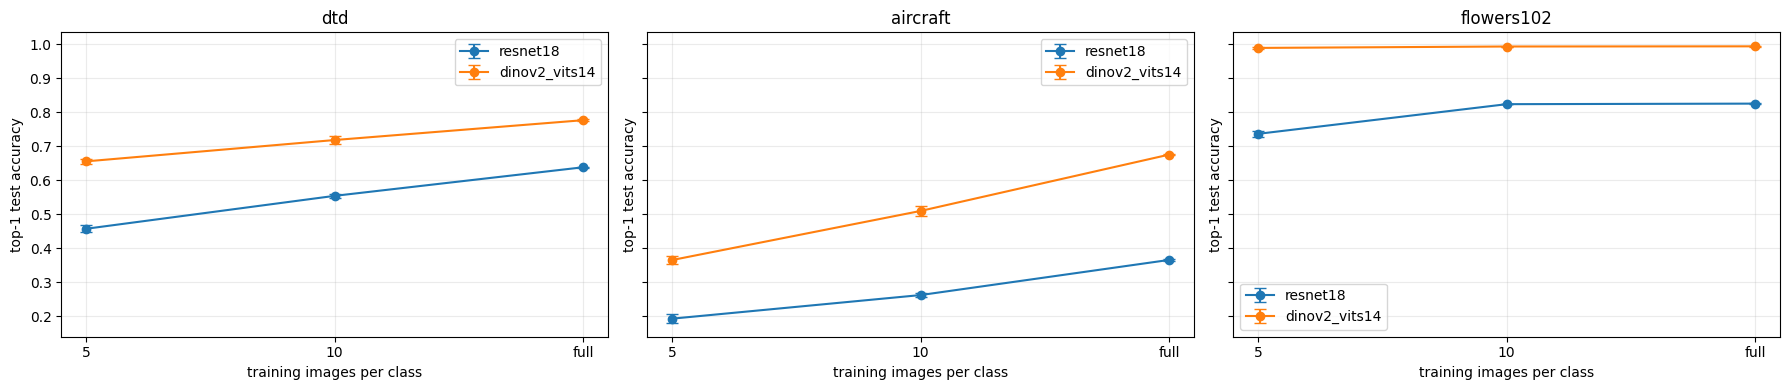

In [8]:
summary = results_df.groupby(['dataset','encoder','shot'], as_index=False).agg(mean_accuracy=('test_accuracy','mean'), std_accuracy=('test_accuracy','std'), runs=('test_accuracy','size'))
summary.to_csv(OUTPUT_ROOT / 'accuracy_summary.csv', index=False)
display(summary.style.format({'mean_accuracy':'{:.4f}', 'std_accuracy':'{:.4f}'}))
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 4), sharey=True, squeeze=False)
axes = axes.ravel()
for ax, dataset_name in zip(axes, DATASETS):
    part = summary[summary.dataset == dataset_name].copy(); part['x'] = part.shot.map({'5':0,'10':1,'full':2})
    for encoder_name in ENCODERS_BY_DATASET[dataset_name]:
        row = part[part.encoder == encoder_name].sort_values('x')
        ax.errorbar(row.x, row.mean_accuracy, yerr=row.std_accuracy.fillna(0), marker='o', capsize=4, label=encoder_name)
    ax.set(title=dataset_name, xticks=[0,1,2], xticklabels=['5','10','full'], xlabel='training images per class', ylabel='top-1 test accuracy'); ax.grid(alpha=.25); ax.legend()
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'accuracy_vs_training_size.png', dpi=180, bbox_inches='tight'); plt.show()


## 9. Representative 10-shot training/validation loss curves
Seed 0 is used consistently as the representative run for each dataset-encoder pair. Each dataset-encoder pair gets two panels: cross-entropy loss (train vs. validation) and validation accuracy over epochs, with a dashed line marking the epoch that was actually checkpointed (highest validation accuracy).

In [ ]:
max_encoders = max(len(v) for v in ENCODERS_BY_DATASET.values())
fig, axes = plt.subplots(len(DATASETS), max_encoders * 2, figsize=(6 * max_encoders * 2, 4 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        h = pd.DataFrame(histories[(dataset_name, encoder_name, '10', 0)])
        loss_ax, acc_ax = axes[i, 2*j], axes[i, 2*j+1]
        loss_ax.plot(h.epoch, h.train_loss, label='train'); loss_ax.plot(h.epoch, h.val_loss, label='validation')
        loss_ax.set(title=f'{dataset_name} / {encoder_name} (loss)', xlabel='epoch', ylabel='cross-entropy'); loss_ax.legend(); loss_ax.grid(alpha=.2)
        best_epoch = h.loc[h.val_accuracy.idxmax(), 'epoch']
        acc_ax.plot(h.epoch, h.val_accuracy, color='green', label='validation accuracy')
        acc_ax.axvline(best_epoch, color='gray', linestyle='--', alpha=.7, label='checkpointed epoch')
        acc_ax.set(title=f'{dataset_name} / {encoder_name} (val accuracy)', xlabel='epoch', ylabel='accuracy', ylim=(0, 1)); acc_ax.legend(); acc_ax.grid(alpha=.2)
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]), max_encoders):
        axes[i, 2*j].axis('off'); axes[i, 2*j+1].axis('off')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'representative_loss_curves.png', dpi=180, bbox_inches='tight'); plt.show()


## 10. Row-normalized confusion matrices
For each dataset, the representative setting is DINOv2, 10-shot, seed 0.

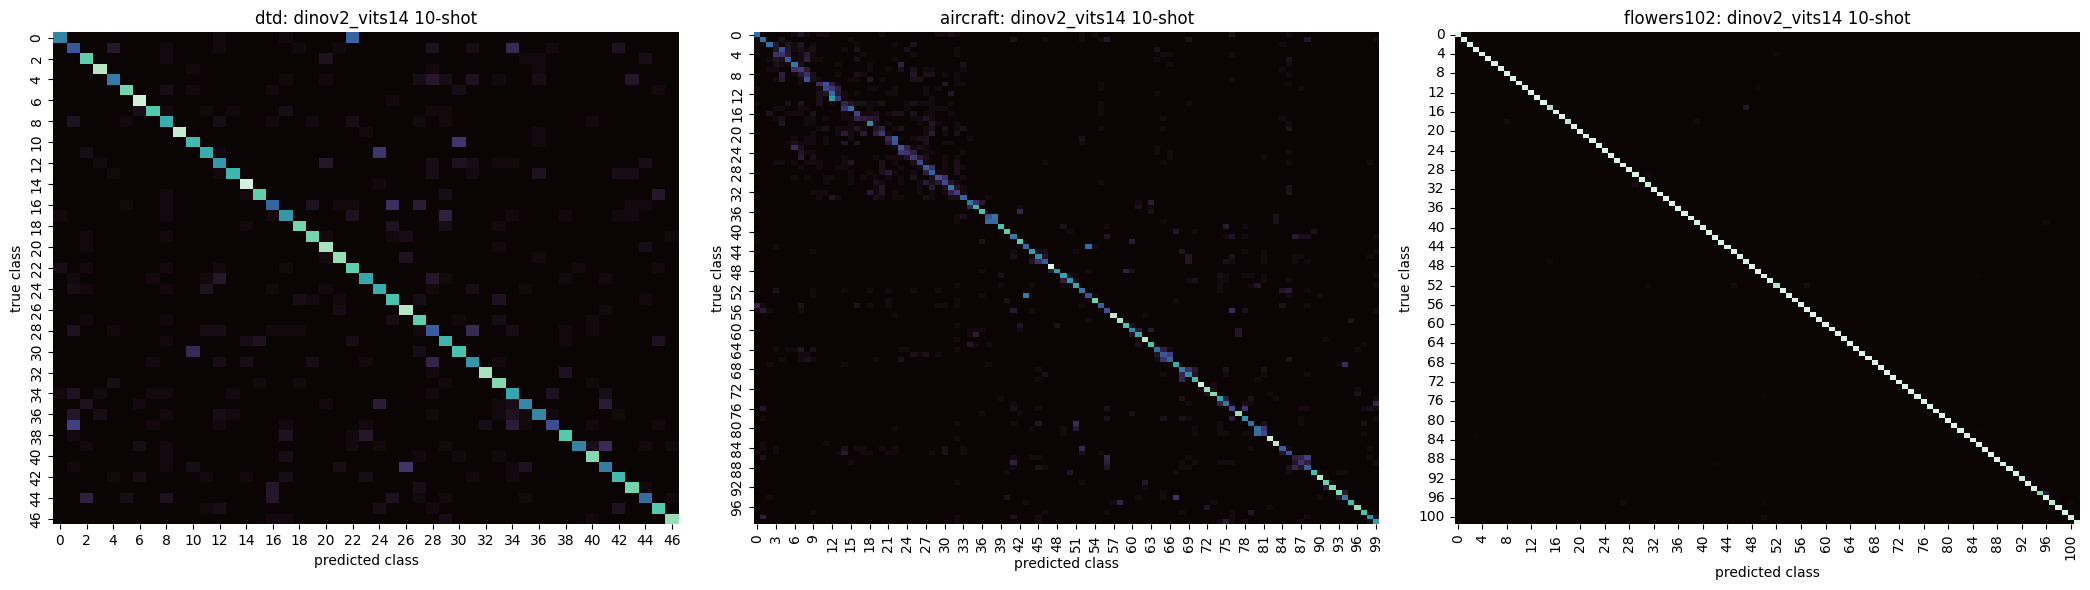

In [10]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(7 * len(DATASETS), 6), squeeze=False); axes = axes.ravel()
for ax, dataset_name in zip(axes, DATASETS):
    encoder_name = ENCODERS_BY_DATASET[dataset_name][-1]
    bank = feature_bank[(dataset_name, encoder_name)]; y = bank['test']['labels'].numpy(); pred = predictions[(dataset_name, encoder_name, '10', 0)].numpy()
    cm = confusion_matrix(y, pred, normalize='true'); sns.heatmap(cm, cmap='mako', vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set(title=f'{dataset_name}: {encoder_name} 10-shot', xlabel='predicted class', ylabel='true class')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'confusion_matrices.png', dpi=180, bbox_inches='tight'); plt.show()


## 11. Comparable feature visualizations
PCA and t-SNE are both fitted to the same deterministic subset of test examples for both encoders, shown side by side per dataset-encoder pair. The first 10 classes and up to 30 test examples per class are used; class colors are fixed within each dataset. These plots are qualitative.

In [ ]:
fig, axes = plt.subplots(len(DATASETS), max_encoders * 2, figsize=(6 * max_encoders * 2, 4 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    selected_classes = np.arange(10); base_labels = feature_bank[(dataset_name, 'resnet18')]['test']['labels'].numpy(); selected_idx = np.concatenate([np.flatnonzero(base_labels == c)[:30] for c in selected_classes])
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        bank = feature_bank[(dataset_name, encoder_name)]['test']; z = F.normalize(bank['features'][selected_idx].float(), dim=1).numpy(); y = bank['labels'][selected_idx].numpy()
        pca_xy = PCA(n_components=2).fit_transform(z)
        perplexity = min(30, max(5, len(z) - 1))
        tsne_xy = TSNE(n_components=2, perplexity=perplexity, init='pca', random_state=0).fit_transform(z)
        pca_ax, tsne_ax = axes[i, 2*j], axes[i, 2*j+1]
        sns.scatterplot(x=pca_xy[:,0], y=pca_xy[:,1], hue=y, palette='tab10', s=22, alpha=.75, ax=pca_ax, legend=False)
        pca_ax.set(title=f'{dataset_name} / {encoder_name} (PCA, L2-normalized)', xlabel='PC1', ylabel='PC2')
        sns.scatterplot(x=tsne_xy[:,0], y=tsne_xy[:,1], hue=y, palette='tab10', s=22, alpha=.75, ax=tsne_ax, legend=(j == len(ENCODERS_BY_DATASET[dataset_name]) - 1))
        tsne_ax.set(title=f'{dataset_name} / {encoder_name} (t-SNE, L2-normalized)', xlabel='dim 1', ylabel='dim 2')
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]), max_encoders):
        axes[i, 2*j].axis('off'); axes[i, 2*j+1].axis('off')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'feature_pca_tsne.png', dpi=180, bbox_inches='tight'); plt.show()
print('Artifacts saved to:', OUTPUT_ROOT)
